<a href="https://colab.research.google.com/github/ananaysaharan/DL_Basics/blob/main/embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tiktoken torch

In [ ]:
import torch
import tiktoken

# Define vocabulary size and embedding dimensions
vocab_size = 50000
embedding_dim = 768

# Create a random embedding matrix
# Using torch.nn.Embedding for a typical embedding layer structure
embedding_matrix = torch.nn.Embedding(vocab_size, embedding_dim)

print(f"Embedding matrix created with shape: {embedding_matrix.weight.shape}")

Embedding matrix created with shape: torch.Size([50000, 768])


In [ ]:
# Initialize tiktoken tokenizer
# Using 'cl100k_base' which is common for OpenAI models like GPT-3.5/4
enc = tiktoken.get_encoding("cl100k_base")

# Example string
example_string = "hello world"

# Tokenize the string
tokens = enc.encode(example_string)

print(f"Original string: '{example_string}'")
print(f"Encoded tokens (integers): {tokens}")
print(f"Decoded tokens: {[enc.decode_single_token_bytes(token) for token in tokens]}")

Original string: 'hello world'
Encoded tokens (integers): [15339, 1917]
Decoded tokens: [b'hello', b' world']


In [ ]:
# Perform embedding lookup
# Convert tokens list to a torch.LongTensor for lookup
tokens_tensor = torch.LongTensor(tokens)

# Get embeddings for the tokens
looked_up_embeddings = embedding_matrix(tokens_tensor)

print(f"\nLooked-up embeddings shape: {looked_up_embeddings.shape}")
print("Embeddings for 'hello world' tokens:")
for i, token_id in enumerate(tokens):
    print(f"  Token ID {token_id} (value: {enc.decode_single_token_bytes(token_id)}):\n{looked_up_embeddings[i].detach().numpy()[:5]}...") # Displaying first 5 dimensions


Looked-up embeddings shape: torch.Size([2, 768])
Embeddings for 'hello world' tokens:
  Token ID 15339 (value: b'hello'):
[-2.3769429   1.4797884  -0.17901053 -1.0039506   0.24905583]...
  Token ID 1917 (value: b' world'):
[ 0.88827986 -1.584247    0.16090019 -0.22631912  2.6828916 ]...


### Using Gensim Word2Vec for Pre-trained Embeddings

Now, let's explore embeddings using a pre-trained Word2Vec model from the `gensim` library. We'll download a common model and then use it to find similar words and perform vector arithmetic.

**Note:** The `word2vec-google-news-300` model is large (~3.6 GB compressed) and may take some time to download.

In [ ]:
# Install gensim
!pip install gensim

In [ ]:
import gensim.downloader as api

# Load the pre-trained Word2Vec model
# This model is ~3.6GB compressed and will take time to download
print("Downloading word2vec-google-news-300 model... This might take a few minutes.")
word_vectors = api.load('word2vec-google-news-300')
print("Model loaded successfully!")

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully!


In [ ]:
print("\nWords similar to 'king':")
# Find the 10 most similar words to 'king'
similar_to_king = word_vectors.most_similar('king', topn=10)
for word, similarity in similar_to_king:
    print(f"  {word}: {similarity:.4f}")


Words similar to 'king':
  kings: 0.7138
  queen: 0.6511
  monarch: 0.6413
  crown_prince: 0.6204
  prince: 0.6160
  sultan: 0.5865
  ruler: 0.5798
  princes: 0.5647
  Prince_Paras: 0.5433
  throne: 0.5422


In [ ]:
print("\nVector arithmetic: 'king - man + woman'")
# Perform vector arithmetic: king - man + woman
# This is often used to find analogies, e.g., 'King is to Man as Queen is to Woman'
result_vector = word_vectors.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)

for word, similarity in result_vector:
    print(f"  The word most similar to 'king - man + woman' is '{word}' with similarity {similarity:.4f}")


Vector arithmetic: 'king - man + woman'
  The word most similar to 'king - man + woman' is 'queen' with similarity 0.7118


### Visualizing Word Embeddings with PCA

To visualize the high-dimensional word embeddings in 2D, we'll use Principal Component Analysis (PCA). We'll select words from different categories (royalty, family, tech, animals), get their embeddings, reduce their dimensions to 2, and then plot them, color-coding by category.

In [5]:
!pip install gensim
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api

# Ensure word_vectors is loaded if not already
# This check prevents re-downloading the large model if it's already in scope from a previous cell.
if 'word_vectors' not in globals():
    print("word_vectors not found in current scope. Attempting to load 'word2vec-google-news-300' model...")
    word_vectors = api.load('word2vec-google-news-300')
    print("Model loaded successfully into the current scope.")

# 1. Define words for different categories
words_royalty = ['king', 'queen', 'prince', 'princess', 'monarch', 'throne']
words_family = ['father', 'mother', 'son', 'daughter', 'brother', 'sister']
words_tech = ['computer', 'software', 'internet', 'algorithm', 'data', 'keyboard']
words_animals = ['cat', 'dog', 'lion', 'tiger', 'elephant', 'giraffe']

# Combine all words and assign categories
all_words = words_royalty + words_family + words_tech + words_animals
categories = (['royalty'] * len(words_royalty)) + \
             (['family'] * len(words_family)) + \
             (['tech'] * len(words_tech)) + \
             (['animals'] * len(words_animals))

# Filter out words not in the vocabulary (if any)
known_words = [word for word in all_words if word in word_vectors.key_to_index]
known_categories = [categories[i] for i, word in enumerate(all_words) if word in word_vectors.key_to_index]

# 2. Get embeddings for the known words
word_embeddings = np.array([word_vectors[word] for word in known_words])

print(f"Number of words with embeddings: {len(known_words)}")
print(f"Shape of embeddings array: {word_embeddings.shape}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.6 MB/s eta 0:00:00
word_vectors not found in current scope. Attempting to load 'word2vec-google-news-300' model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Model loaded successfully into the current scope.
Number of words with embeddings: 24
Shape of embeddings array: (24, 300)


Shape of reduced embeddings array: (24, 2)


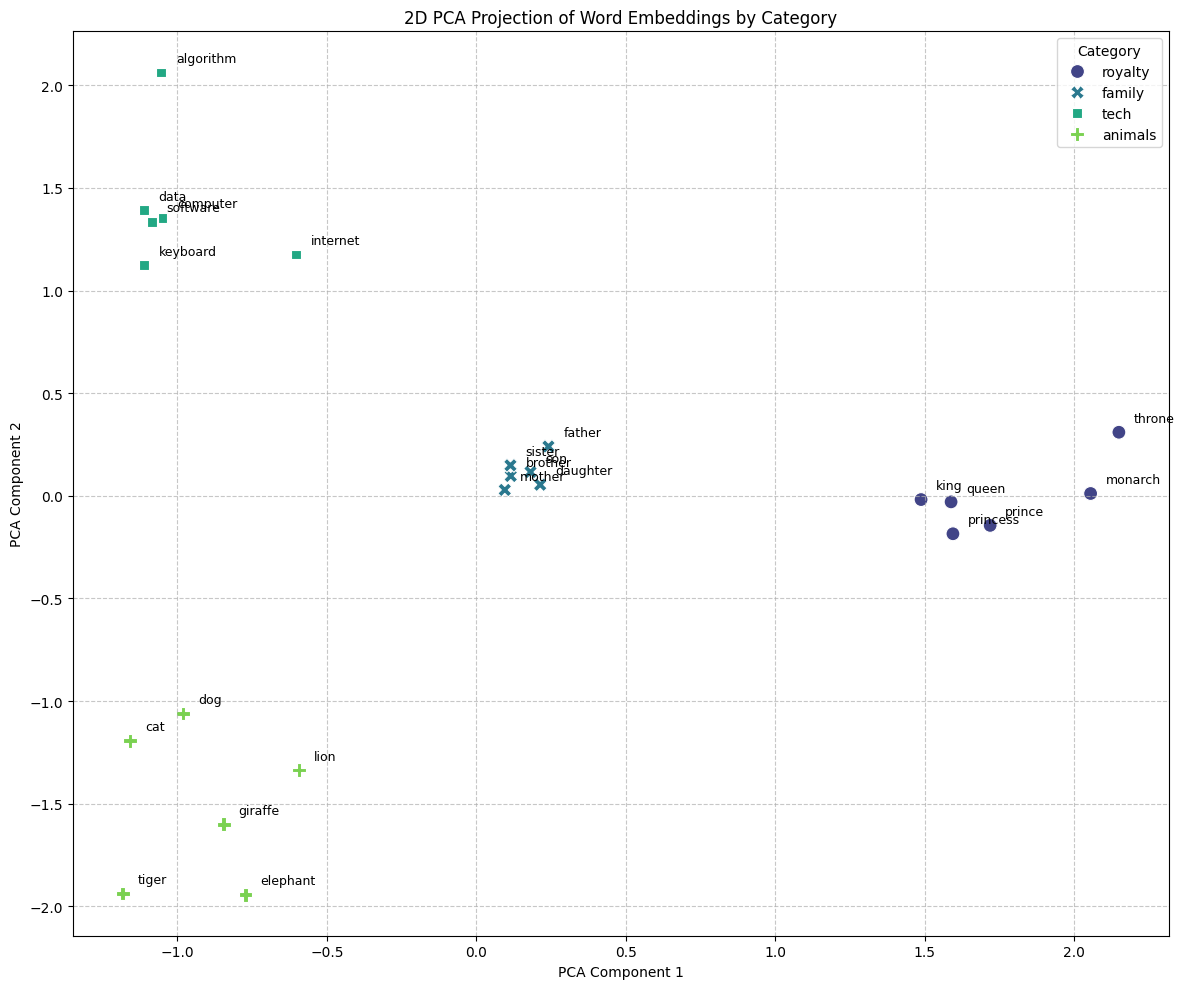

In [6]:
# 3. Apply PCA to reduce dimensionality to 2D
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(word_embeddings)

print(f"Shape of reduced embeddings array: {reduced_embeddings.shape}")

# Create a DataFrame for easier plotting with seaborn
import pandas as pd
df_plot = pd.DataFrame({
    'word': known_words,
    'x': reduced_embeddings[:, 0],
    'y': reduced_embeddings[:, 1],
    'category': known_categories
})

# 4. Plot the 2D embeddings
plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=df_plot,
    x='x',
    y='y',
    hue='category',
    style='category',
    s=100, # size of the points
    palette='viridis' # color scheme
)

# Add word labels to the plot
for i, row in df_plot.iterrows():
    plt.annotate(row['word'], (row['x'] + 0.05, row['y'] + 0.05), fontsize=9)

plt.title('2D PCA Projection of Word Embeddings by Category')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Category')
plt.tight_layout()
plt.show()